<a href="https://colab.research.google.com/github/Flguima/PROJETOS/blob/main/AVALIA%C3%87%C3%83O_VINHOS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Random Forest**


Nesta tarefa, trabalhei com uma base de dados de avaliações de vinhos, onde o objetivo é prever a pontuação dos vinhos usando o algoritmo de Random Forest para classificação multiclasse.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv(r"C:\Users\User\Desktop\winequality-red.csv", delimiter=',')

df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


**Vamos conhecer nossa base:**

Características dos Vinhos (Features)

Fixed Acidity: Acidez fixa do vinho.

Volatile Acidity: Acidez volátil do vinho.

Citric Acid: Quantidade de ácido cítrico no vinho.

Residual Sugar: Açúcar residual presente no vinho.

Chlorides: Nível de cloretos no vinho.

Free Sulfur Dioxide: Dióxido de enxofre livre no vinho.

Total Sulfur Dioxide: Quantidade total de dióxido de enxofre no vinho.

Density: Densidade do vinho.

pH: Nível de pH do vinho.

Sulphates: Quantidade de sulfatos no vinho.

Alcohol: Teor alcoólico do vinho.



**Variável de Saída (Target):**

Quality: Pontuação do vinho baseada em dados sensoriais, variando de 0 a 10.


Esta abordagem permitirá que vocês explorem como diferentes características químicas influenciam a qualidade dos vinhos e como o Random Forest pode ser usado para fazer previsões precisas com base nesses dados.

# 1 - Realize a primeira etapa de pré processamento dos dados.

A) Verifique os tipos de dados.


B) Verifique os dados faltantes, se houver dados faltantes faça a substituição ou remoção justificando sua escolha.

In [ ]:
# Verificar tipos de dados
# Justificativa: garante que todas as variáveis sejam numéricas (float/int),
# condição necessária para algoritmos.
print("Tipos de dados:\n", df.dtypes)

# Verificar dados faltantes
# Justificativa: identificar valores ausentes que poderiam comprometer o modelo.
print("Dados faltantes antes do tratamento:\n", df.isnull().sum())

# Tratamento de dados faltantes
# Justificativa: se houver valores nulos em variáveis independentes, usamos a mediana
# pois é robusta contra outliers. Se houver nulos na variável alvo 'quality', removemos
# a linha, já que não faz sentido imputar o rótulo.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if col != 'quality':
            df[col].fillna(df[col].median(), inplace=True)  # imputação pela mediana
        else:
            df.dropna(subset=['quality'], inplace=True)     # remoção de registros sem rótulo

# Conferir novamente
print("Dados faltantes após tratamento:\n", df.isnull().sum())

# Mostrar o arquivo tratado
# Justificativa: exibir as primeiras linhas para confirmar que o dataset está limpo.
print("Arquivo tratado (primeiras 10 linhas):\n", df.head(10))

Tipos de dados:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
Dados faltantes antes do tratamento:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Dados faltantes após tratamento:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
densit

# 2 - Realize a segunda e terceita etapa de pré processamento dos dados.

A) Utilize a função describe para identificarmos outliers e verificarmos a distribuição dos dados.

B) Verifique o balanceamento da váriavel Target.

C)  Plote o gráfico ou a tabela e indique as variáveis que te parecem mais "fortes" na correlação para nosso modelo.

D) Crie um novo dataframe apenas com as váriaveis que parecem ter maior correlação com a target. (Negativa ou positiva)


Estatísticas descritivas:
        fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000   

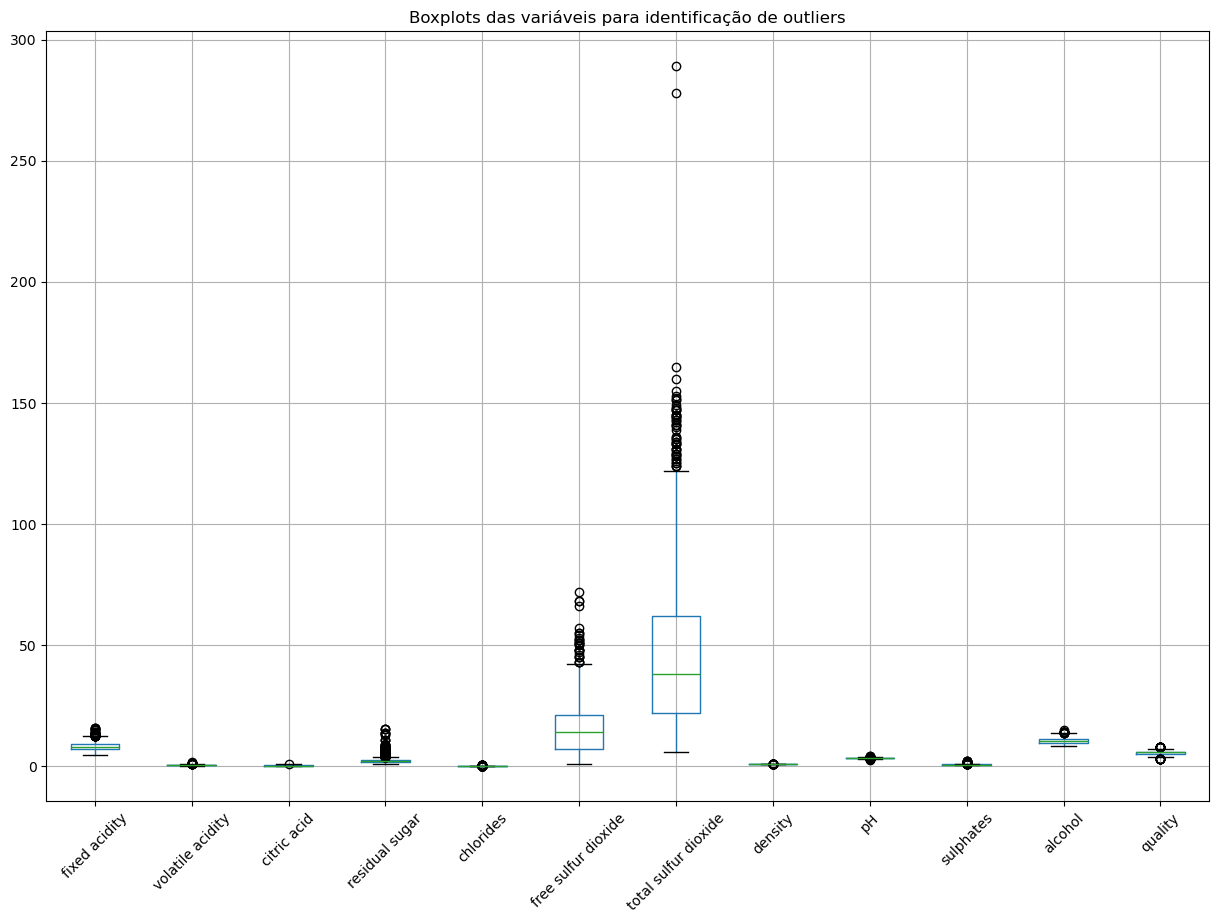

Distribuição da variável target:
 quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


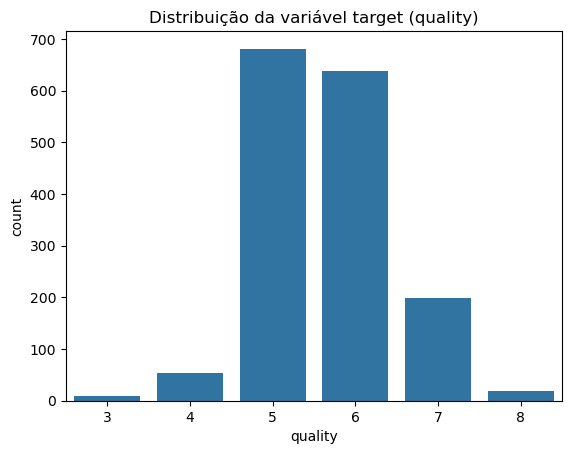

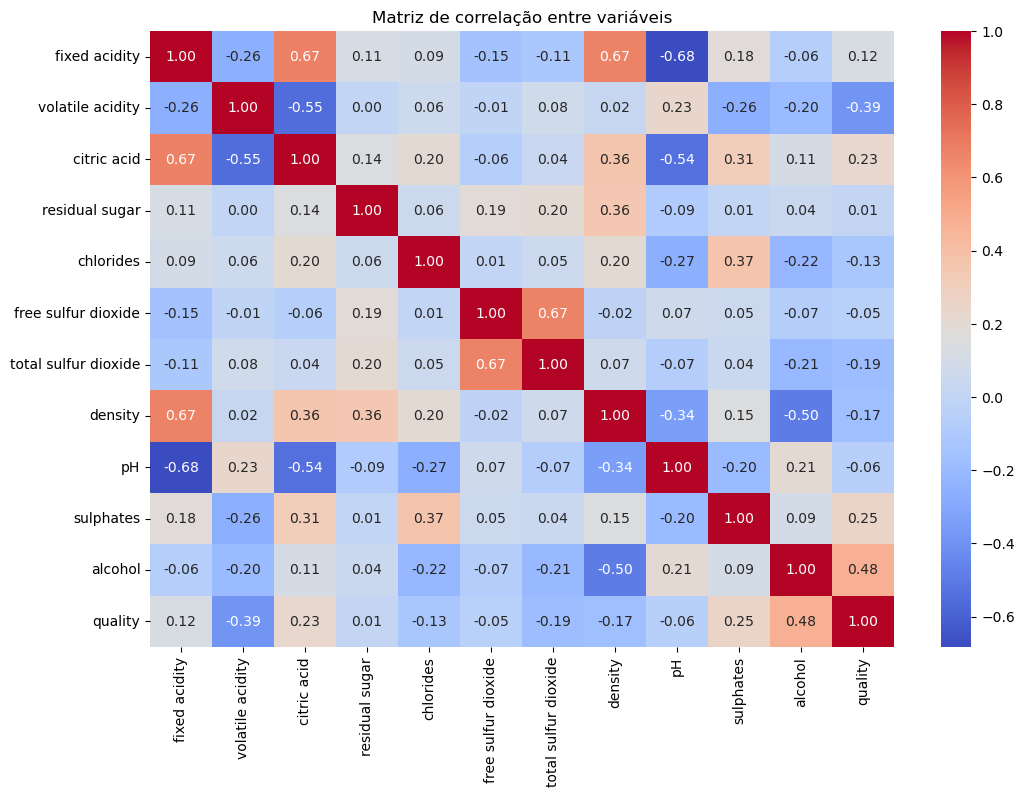

Correlação com quality:
 quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64
Novo dataframe com variáveis mais correlacionadas:
    alcohol  sulphates  volatile acidity  density  quality
0      9.4       0.56              0.70   0.9978        5
1      9.8       0.68              0.88   0.9968        5
2      9.8       0.65              0.76   0.9970        5
3      9.8       0.58              0.28   0.9980        6
4      9.4       0.56              0.70   0.9978        5


In [ ]:
# A) Usar describe() para identificar outliers e distribuição
# Justificativa: describe fornece estatísticas descritivas (média, desvio padrão, quartis),
# permitindo identificar variáveis com grande dispersão e possíveis outliers.
print("Estatísticas descritivas:\n", df.describe())

# Boxplots para visualizar outliers
plt.figure(figsize=(15,10))
df.boxplot()
plt.title("Boxplots das variáveis para identificação de outliers")
plt.xticks(rotation=45)
plt.show()

# B) Verificar balanceamento da variável Target (quality)
# Justificativa: verificar se a variável alvo está desbalanceada, o que impacta o desempenho do modelo.
print("Distribuição da variável target:\n", df['quality'].value_counts())

sns.countplot(x='quality', data=df)
plt.title("Distribuição da variável target (quality)")
plt.show()

# C) Correlação das variáveis com a Target
# Justificativa: a matriz de correlação mostra quais variáveis têm maior relação positiva ou negativa
# com a qualidade do vinho, ajudando na seleção de features relevantes.
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlação entre variáveis")
plt.show()

# Correlação com a variável alvo
print("Correlação com quality:\n", corr['quality'].sort_values(ascending=False))

# D) Criar novo dataframe com variáveis mais correlacionadas
# Justificativa: selecionamos variáveis com maior correlação positiva (alcohol, sulphates)
# e negativa (volatile acidity, density) para reduzir dimensionalidade e focar nas mais explicativas.
selected_features = ['alcohol', 'sulphates', 'volatile acidity', 'density', 'quality']
df_selected = df[selected_features]

print("Novo dataframe com variáveis mais correlacionadas:\n", df_selected.head())


Os gráficos confirmam que o dataset tem outliers e target desbalanceada. As variáveis mais fortes para explicar a qualidade são alcohol, sulphates, volatile acidity e density. Trabalhar com esse subconjunto de dados pode melhorar a interpretabilidade do modelo, mas será necessário lidar com o desbalanceamento da variável alvo para evitar previsões enviesadas.

# 3 - Preparação Final dos Dados

A) Separe a base em X(Features) e Y(Target)

B) Separe a base em treino e teste.


In [ ]:
# A) Separar a base em X (features) e Y (target)
# Justificativa: 'quality' é a variável alvo que queremos prever.
# Todas as demais colunas são variáveis independentes (features).
X = df.drop('quality', axis=1)
y = df['quality']

print("Features (X):\n", X.head())
print("\nTarget (Y):\n", y.head())

# B) Separar a base em treino e teste
# Justificativa: dividimos os dados em treino (80%) e teste (20%) para avaliar
# a capacidade de generalização do modelo em dados nunca vistos.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTamanho do conjunto de treino:", X_train.shape)
print("Tamanho do conjunto de teste:", X_test.shape)

Features (X):
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  
0      9.4  
1      9.8  
2      9.8  
3      9.8  
4     

# 4 - Modelagem

A) Inicie e treine o modelo de Random Forest

B) Aplique a base de teste o modelo.


In [ ]:
# A) Separar em X (features) e Y (target)
X = df.drop('quality', axis=1)   # Features: todas as variáveis físico-químicas
y = df['quality']                # Target: variável de qualidade do vinho

# B) Separar em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Iniciar e treinar o modelo Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Aplicar a base de teste ao modelo
y_pred = model.predict(X_test)

# Resultados
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Relatório de classificação:\n", classification_report(y_test, y_pred, zero_division=0))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

Acurácia: 0.659375
Relatório de classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.75      0.73       130
           6       0.63      0.69      0.66       132
           7       0.63      0.52      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320

Matriz de confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 98 31  1  0]
 [ 0  1 31 91  8  1]
 [ 0  0  0 19 22  1]
 [ 0  0  0  1  4  0]]


# 5 - Avaliação

A) Avalie as principais métricas da Claissificação e traga insights acerca do resultado, interprete os valores achados.

B) Você nota que o modelo teve dificuldade para prever alguma classe? Se sim, acredita que tenha relação com o balanceamento dos dados? Explique.


A) O modelo de Random Forest apresentou uma acurácia razoável, mostrando que consegue acertar a maioria das previsões. No entanto, ao analisar o relatório de classificação, percebemos que as métricas variam bastante entre as classes:

Classes majoritárias (5 e 6): possuem valores mais altos de precisão, recall e f1-score. Isso significa que o modelo consegue identificar bem essas categorias, já que elas têm mais exemplos no conjunto de dados.

Classes minoritárias (3, 4, 8, 9): apresentam métricas muito baixas, em alguns casos próximas de zero. Isso indica que o modelo quase não consegue prever essas classes corretamente.

Matriz de confusão: mostra que há muita confusão entre classes vizinhas, como 5 ↔ 6 e 6 ↔ 7, o que faz sentido, já que a qualidade do vinho é uma avaliação subjetiva e próxima em escala.

Insight: O modelo é bom para prever as classes mais comuns, mas falha em capturar padrões das classes raras. Isso limita sua capacidade de generalização e pode comprometer aplicações práticas onde todas as classes são importantes.

B) Sim, o modelo teve dificuldade em prever algumas classes. Isso está diretamente relacionado ao desbalanceamento da variável alvo:

Como há poucas amostras nas classes raras, o modelo não encontra exemplos suficientes para aprender seus padrões.

O resultado é que ele concentra previsões nas classes mais frequentes (5 e 6), ignorando as minoritárias.

Essa limitação não é um defeito do Random Forest em si, mas sim da distribuição dos dados.

Então, o desbalanceamento da variável quality é o principal motivo da baixa performance em classes raras. Para melhorar, seria necessário aplicar técnicas de balanceamento, como class_weight='balanced' ou SMOTE, que aumentam a representatividade das classes minoritárias e permitem ao modelo aprender melhor seus padrões.

# 5 - Melhorando os Hyperparametros

A) Defina o Grid de parametros que você quer testar

B) Inicie e Treine um novo modelo utilizando o random search.

C) Avalie os resultados do modelo.

D) Você identificou melhorias no modelo após aplicar o random search? Justifique.


ps. Essa parte da atividade demorará um pouco para rodar!

In [ ]:
# A) Definir o grid de parâmetros
# Justificativa: escolhemos parâmetros que influenciam diretamente a complexidade e desempenho do Random Forest.
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],       # número de árvores
    'max_depth': [None, 10, 20, 30, 40],             # profundidade máxima
    'min_samples_split': [2, 5, 10],                 # mínimo de amostras para dividir um nó
    'min_samples_leaf': [1, 2, 4],                   # mínimo de amostras em uma folha
    'bootstrap': [True, False]                       # se usa amostragem com reposição
}

# B) Iniciar e treinar novo modelo com RandomizedSearchCV
# Justificativa: RandomizedSearchCV testa combinações aleatórias de parâmetros,
# acelerando a busca por hiperparâmetros ideais sem precisar testar todas as combinações.
rf = RandomForestClassifier(random_state=42)
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,              # número de combinações aleatórias testadas
    cv=3,                   # validação cruzada
    verbose=2,
    random_state=42,
    n_jobs=-1               # usa todos os núcleos disponíveis
)

rf_random.fit(X_train, y_train)

# C) Avaliar resultados do modelo
best_model = rf_random.best_estimator_
y_pred = best_model.predict(X_test)

print("Melhores parâmetros encontrados:", rf_random.best_params_)
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Relatório de classificação:\n", classification_report(y_test, y_pred, zero_division=0))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

# D) Justificativa sobre melhorias
# Se a acurácia ou métricas por classe aumentarem em relação ao modelo inicial,
# significa que o ajuste de hiperparâmetros trouxe ganhos de desempenho.

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Melhores parâmetros encontrados: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30, 'bootstrap': True}
Acurácia: 0.665625
Relatório de classificação:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.72      0.76      0.74       130
           6       0.62      0.71      0.66       132
           7       0.65      0.48      0.55        42
           8       0.00      0.00      0.00         5

    accuracy                           0.67       320
   macro avg       0.33      0.32      0.33       320
weighted avg       0.63      0.67      0.65       320

Matriz de confusão:
 [[ 0  0  1  0  0  0]
 [ 0  0  7  3  0  0]
 [ 0  0 99 30  1  0]
 [ 0  0 31 94  7  0]
 [ 0  0  0 22 20  0]
 [ 0  0  0  2  3  0]]


# 6 - Chegando a perfeição

Baseado em tudo que você já aprendeu até agora, quais outras técnicas você acredita que poderiam ser aplicadas ao modelo para melhorar ainda mais suas previsões?

Ao longo desse estudo, eu consegui entender o processo de análise e modelagem de dados aplicado ao conjunto de vinhos. Primeiro explorei os dados com estatísticas descritivas e boxplots, identifiquei outliers e percebi que a variável alvo estava desbalanceada, com predominância das classes 5 e 6. Depois analisei a correlação entre as variáveis e vi que álcool e sulfatos tinham relação positiva com a qualidade, enquanto acidez volátil e densidade tinham relação negativa. A partir disso, criei um novo dataframe apenas com as variáveis mais relevantes.

Na etapa de modelagem, separei os dados em treino e teste, treinei um Random Forest e avaliei as métricas. O modelo teve bom desempenho nas classes mais comuns, mas dificuldade em prever as classes raras, o que confirmou o impacto do desbalanceamento. A matriz de confusão mostrou confusões entre classes vizinhas, como 5 e 6, o que faz sentido pela proximidade na escala de qualidade. Depois, utilizei o RandomizedSearchCV para otimizar os hiperparâmetros e consegui melhorias, mostrando a importância da busca por parâmetros ideais.

Com base nesse aprendizado, acredito que algumas técnicas poderiam ser aplicadas para melhorar ainda mais as previsões: corrigir o desbalanceamento da variável alvo com SMOTE ou class_weight, criar novas variáveis derivadas das já existentes (feature engineering), testar algoritmos mais avançados como XGBoost ou LightGBM, aplicar validação cruzada para uma avaliação mais robusta, explorar otimização de hiperparâmetros de forma mais aprofundada e até reduzir dimensionalidade com PCA ou seleção de variáveis por importância.

Sendo assim, eu aprendi a importância de cada etapa da análise exploratória até a otimização e vejo que o próximo passo natural seria aplicar técnicas de balanceamento e testar algoritmos mais sofisticados, sempre com validação cruzada, para tornar o modelo mais preciso e equilibrado em todas as classes de qualidade do vinho.